In [ ]:
pip install datasets transformers torch

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
train_dataset = load_dataset("ai4bharat/indic_glue", "bbca.hi", split="train")
test_dataset  = load_dataset("ai4bharat/indic_glue", "bbca.hi", split="test")
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 3467
Test size: 866


In [ ]:
model_name = "ai4bharat/IndicBERTv2-MLM-only"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(250000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [ ]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [ ]:
def get_embeddings(texts, batch_size=16):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        pooled = mean_pooling(outputs, inputs["attention_mask"])
        embeddings.append(pooled.cpu())
    return torch.cat(embeddings, dim=0)
train_embeddings = get_embeddings(train_dataset["text"])
print("Generating validation embeddings...",train_embeddings)
test_embeddings = get_embeddings(test_dataset["text"])
print("Generating test embeddings...",test_embeddings)
X_train = train_embeddings.numpy()
X_test = test_embeddings.numpy()
y_train = np.array(train_dataset["label"])
y_test = np.array(test_dataset["label"])

Generating validation embeddings... tensor([[-0.0043, -0.0114, -0.0645,  ...,  0.0747,  0.0584,  0.1220],
        [-0.0033, -0.0578, -0.0637,  ...,  0.0314,  0.0959,  0.0709],
        [ 0.0225, -0.0208, -0.1830,  ...,  0.0433,  0.0892,  0.0608],
        ...,
        [-0.0304, -0.0297, -0.1627,  ...,  0.0835,  0.0212,  0.1135],
        [ 0.0068,  0.0244, -0.0527,  ...,  0.0469,  0.0738,  0.1144],
        [ 0.0184,  0.0452, -0.0561,  ...,  0.0276,  0.0557,  0.1159]])
Generating test embeddings... tensor([[-0.0457, -0.0222, -0.1872,  ...,  0.0467,  0.0960,  0.1179],
        [ 0.0030, -0.0018, -0.0719,  ...,  0.0465,  0.0586,  0.0617],
        [-0.0209,  0.0086, -0.0845,  ...,  0.0328,  0.1136,  0.1385],
        ...,
        [ 0.0146,  0.0012, -0.1611,  ...,  0.0511,  0.1025,  0.0722],
        [-0.0237, -0.0027, -0.1023,  ..., -0.0122,  0.1067,  0.0824],
        [ 0.0214,  0.0061, -0.1219,  ...,  0.0132,  0.1750,  0.1297]])


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.9s finished


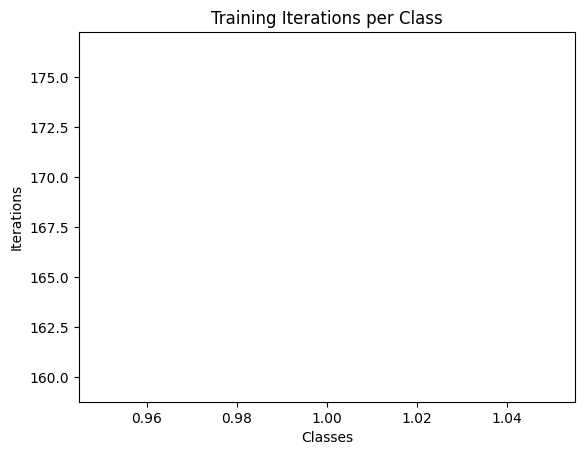

In [ ]:
clf = LogisticRegression(max_iter=2000, verbose=1)
clf.fit(X_train, y_train)
loss_values = clf.n_iter_
plt.figure()
plt.plot(range(1, len(loss_values)+1), loss_values)
plt.xlabel("Classes")
plt.ylabel("Iterations")
plt.title("Training Iterations per Class")
plt.show()

In [ ]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7159353348729792

Classification Report:

                 precision    recall  f1-score   support

       business       0.20      0.14      0.17         7
          china       0.00      0.00      0.00         5
  entertainment       0.77      0.79      0.78        71
          india       0.87      0.85      0.86       357
  institutional       0.60      0.75      0.67         4
  international       0.61      0.66      0.63       212
learningenglish       0.00      0.00      0.00         3
     multimedia       0.00      0.00      0.00         1
           news       0.18      0.18      0.18        49
       pakistan       0.12      0.12      0.12         8
        science       0.70      0.64      0.67        61
         social       0.67      0.33      0.44         6
      southasia       0.10      0.10      0.10        10
          sport       0.85      0.89      0.87        72

       accuracy                           0.72       866
      macro avg       0.40     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


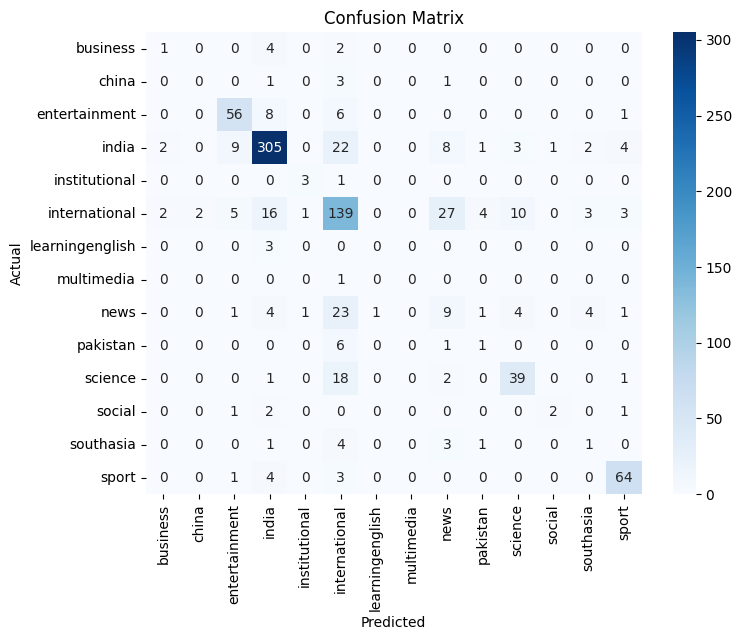

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()